In [1]:
from typing import List, TypedDict, Literal
from pydantic import BaseModel, Field
import time
import os
from langchain_openrouter import ChatOpenRouter
from langchain_ollama import OllamaEmbeddings
from langchain_community.document_loaders import PyPDFLoader
from langchain_groq import ChatGroq
from langchain_chroma import Chroma
from langchain_google_genai import  ChatGoogleGenerativeAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import OpenAIEmbeddings
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv

load_dotenv()

C:\Users\Ritika Khandelwal\AppData\Local\Temp\ipykernel_5892\3639166626.py:7: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


True

In [2]:
docs = (PyPDFLoader("./documents/Company_Policies.pdf").load()+ 
        PyPDFLoader("./documents/Company_Profile.pdf").load()+
        PyPDFLoader("./documents/Product_and_Pricing.pdf").load())



incorrect startxref pointer(1)
parsing for Object Streams
incorrect startxref pointer(1)
parsing for Object Streams
incorrect startxref pointer(1)
parsing for Object Streams


In [3]:
llm1 = ChatGoogleGenerativeAI(model='gemini-2.5-flash', temperature=0, api_key=os.environ.get('GOOGLE_API_KEY_2'))
llm2 = ChatGoogleGenerativeAI(model='gemini-2.5-flash', temperature=0, api_key=os.environ.get('GOOGLE_API_KEY'))
groqllm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0
)

llm=llm1.with_fallbacks([llm2])


In [4]:
# llm = ChatOpenRouter(
#     model='openrouter/free',
#     temperature=0
# )

In [5]:
# This is a google cloud llm instance
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    vertexai=True,
    project="ai-api-2335",  # Replace with your GCP project ID
    location="us-central1",
    temperature=0
)

In [6]:
chunks = RecursiveCharacterTextSplitter(
    chunk_size=600,
    chunk_overlap=150
).split_documents(docs)

In [7]:
embeddings = OllamaEmbeddings(model="mxbai-embed-large")

persist_directory = "./chroma_db"

if os.path.exists(persist_directory):
    print("Loading existing vector database...")
    vector_store = Chroma(
        persist_directory=persist_directory,
        embedding_function=embeddings,
        collection_name="company_knowledge_base"
    )
else:
    print("Creating embeddings for the first time...")
    vector_store = Chroma.from_documents(
        documents=docs,
        embedding=embeddings,
        persist_directory=persist_directory,
        collection_name="company_knowledge_base"
    )

Loading existing vector database...


In [8]:
query = "Write a company overview?"
retriever = vector_store.as_retriever(search_kwargs={"k": 4})  # Get top 4 matching pages


In [9]:
class State(TypedDict):
    question: str
    need_retrieval: bool
    docs: List[Document]
    answer: str
    context: str
    relevant_docs:List[Document]
    # Post-generation verification
    issup: Literal["fully_supported", "partially_supported", "no_support"]
    evidence: List[str]
    
    retries: int
    isuse:Literal['useful', 'not_useful']
    retrieval_query: str
    rewrite_tries: int

In [10]:
class RetrieveDecision(BaseModel):
    should_retrieve : bool = Field(description='True if external documents are needed to answer reliably, else False')

decide_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You decide whether retrieval is needed.\n"
            "Return JSON that matches this schema:\n"
            "{{'should_retrieve': boolean}}\n\n"
            "Guidelines:\n"
            "- should_retrieve=True if answering requires specific facts, citations, or info likely not in the model.\n"
            "- should_retrieve=False for general explanations, definitions, or reasoning that doesn't need sources.\n"
            "- If unsure, choose True."
        ),
        ("human", "Question: {question}"),
    ]
)

def decide_retrieval(state : State):
    should_retrieve_llm = llm.with_structured_output(RetrieveDecision)
    chain = decide_retrieval_prompt | should_retrieve_llm 
    decision=chain.invoke({'question' : state["question"]})
    # print("Needs Retieval : ",decision.should_retrieve)
    return {'need_retrieval' : decision.should_retrieve}

In [11]:
def direct_ans(state : State):
    direct_ans_prompt = ChatPromptTemplate.from_messages([
        ('system','You are an ai assistant, answer this questio from your knowledge base and training data, DO NOT assume access to external documents.' "If you are unsure or the answer requires specific sources, say:\n"
        "'I don't know based on my general knowledge.'"
            ),
            ('human','{question}')

    ])

    ans = llm.invoke(
        direct_ans_prompt.format_messages(
            question=state["question"]
        )
    )
    return {"answer" : ans.content}

In [12]:
def retrieve(state: State):
    q = state.get("retrieval_query") or state["question"]
    return {"docs": retriever.invoke(q)}

In [13]:
def route_after_decide(state : State) -> Literal['direct','retrieve']:
    if (state['need_retrieval']):
        return 'retrieve'
    else:
        return 'direct'


In [14]:
# # Is Relevant Node
# class GradeDocument(BaseModel):
#     is_relevant: bool = Field(description="True if the document helps answer the question")

# is_rel_prompt = ChatPromptTemplate.from_messages([
#     (
#         "system",
#         "You are an AI assistant which is expert at judging document relevance.\n\n"
#         "Return JSON that matches this schema:\n"
#         "{{\"is_relevant\": boolean}}\n\n"
#         "A document is relevant if it contains information useful for answering the question."
#     ),
#     (
#         "human",
#         "Question : {question}\n"
#         "Context : {context}"
#     )
# ])

# def is_relevant(state: State):
#     rel_docs: List[Document] = []
#     try:
#             str_llm = llm.with_structured_output(GradeDocument)
#             for doc in state.get("docs", []):
#                     llm_res = str_llm.invoke(
#                         is_rel_prompt.format_messages(
#                         question=state["question"],
#                         context=doc.page_content
#                     )
#                 )
#                     # print(llm_res)
#                     if llm_res.is_relevant:
#                         rel_docs.append(doc)
#             return {"relevant_docs": rel_docs}
#     except Exception as e:
#         print(e)
#         return
    

In [15]:
# -----------------------------
# 4) Relevance filter (Single Call)
# -----------------------------
class DocGrade(BaseModel):
  doc_index: int = Field(
      description="0-based index of the document being evaluated."
  )
  is_relevant: bool = Field(description="True if relevant, else False.")


class AllDocsRelevance(BaseModel):
  grades: List[DocGrade] = Field(
      description="Relevance decisions for each document index."
  )


all_docs_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        "You are evaluating the relevance of multiple retrieved documents to a"
        " user query at a TOPIC level.\n"
        "Return JSON listing whether each document is relevant.\n"
        "A document is relevant if it relates to the topic or entity in the"
        " query.\n"
        "If unsure, mark is_relevant=True.",
    ),
    ("human", "Query: {question}\n\nDocuments:\n{formatted_docs}"),
])

all_relevance_chain = all_docs_prompt | llm.with_structured_output(
    AllDocsRelevance
)


def is_relevant(state: State):
  docs = state.get("docs", [])
  if not docs:
    return {"relevant_docs": []}

  active_query = state.get("retrieval_query") or state.get("question", "")

  # Format all docs into an indexed list
  formatted_docs = "\n\n".join(
      f"--- [Doc {i}] ---\n{doc.page_content}" for i, doc in enumerate(docs)
  )

  decision: AllDocsRelevance = all_relevance_chain.invoke({
      "question": active_query,
      "formatted_docs": formatted_docs,
  })

  relevant_indices = {
      g.doc_index for g in decision.grades if g.is_relevant and g.doc_index >= 0
  }

  relevant_docs = [
      doc for i, doc in enumerate(docs) if i in relevant_indices]  

  return {"relevant_docs": relevant_docs}

In [16]:
#RAG Generation
rag_prompt = ChatPromptTemplate.from_messages([
    ('system',"""
You are an expert AI Business RAG assistant
answer the question as per the given context. DO NOT assume any information on your own
If the context does not contain enough information about the question, say "Not enough Information found"
Do not use Markdown bold formatting. Never enclose words or phrases in double asterisks (**word**). Format all output in clean, plain text without bolding, italics, or markdown headers. Use capitalization or plain bullet points (-) for emphasis and structure if needed.
 """),
 (
     "human", """
Question : {question}
Context : {context}
"""
 )
])

def generate_from_context(state: State):
    # Stuff relevant docs into one block
    context = "\n\n---\n\n".join(
        [d.page_content for d in state.get("relevant_docs", [])]
    ).strip()

    if not context:
        return {"answer": "No relevant document found.", "context": ""}

    try:
        out = llm.invoke(
                rag_prompt.format_messages(
                    question=state["question"],
                    context=context
                )
            )
        return {"answer": out.content, "context": context}
    except Exception as e:
        print(f"Generation Error: {e}")
        return {"answer": "An error occurred during generation.", "context": context}


In [17]:
def no_relevant_docs(state: State):
    return {"answer": "No relevant document found.", "context": ""}

In [18]:
def route_after_relevance(state: State) -> Literal["generate_from_context", "no_relevant_docs"]:
    if state.get("relevant_docs") and len(state["relevant_docs"]) > 0:
        return "generate_from_context"
    return "no_relevant_docs"

Is Supported Node

In [19]:
class issup(BaseModel):
    issup: Literal['fully_supported', 'partially_supported', 'no_support'] = Field(
        description="Must be one of 'fully_supported', 'partially_supported', or 'no_support'"
    )
    evidence: List[str] = Field(default_factory=list, description="Up to 3 short direct quotes from CONTEXT that support the supported parts.")

issup_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are verifying whether the ANSWER is supported by the CONTEXT.\n"
            "Return JSON with keys: issup, evidence.\n"
            "issup must be one of: fully_supported, partially_supported, no_support.\n\n"
            "How to decide issup:\n"
            "- fully_supported:\n"
            "  Every meaningful claim is explicitly supported by CONTEXT, and the ANSWER does NOT introduce\n"
            "  any qualitative/interpretive words that are not present in CONTEXT.\n"
            "  (Examples of disallowed words unless present in CONTEXT: culture, generous, robust, designed to,\n"
            "  supports professional development, best-in-class, employee-first, etc.)\n\n"
            "- partially_supported:\n"
            "  The core facts are supported, BUT the ANSWER includes ANY abstraction, interpretation, or qualitative\n"
            "  phrasing not explicitly stated in CONTEXT (e.g., calling policies 'culture', saying leave is 'generous',\n"
            "  or inferring outcomes like 'supports professional development').\n\n"
            "- no_support:\n"
            "  The key claims are not supported by CONTEXT.\n\n"
            "Rules:\n"
            "- Be strict: if you see ANY unsupported qualitative/interpretive phrasing, choose partially_supported.\n"
            "- If the answer is mostly unrelated to the question or unsupported, choose no_support.\n"
            "- Evidence: include up to 3 short direct quotes from CONTEXT that support the supported parts.\n"
            "- Do not use outside knowledge."
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Answer:\n{answer}\n\n"
            "Context:\n{context}\n"
        ),
    ]
)


issup_llm = llm.with_structured_output(issup)
issup_chain = issup_prompt | issup_llm


# def is_sup(state: State):
#     decision: issup = issup_chain.invoke({
#         "question": state.get("question", ""),
#         "answer": state.get("answer", ""),
#         "context": state.get("context", ""),
#     })
#     return {"issup": decision.issup, "evidence": decision.evidence}

def is_sup(state: State):
    decision = issup_chain.invoke({
        "question": state.get("question", ""),
        "answer": state.get("answer", ""),
        "context": state.get("context", ""),
    })
    
    # Safeguard against API quota limits or safety blocks returning None
    if not decision:
        print("Warning: is_sup returned None. Defaulting to no_support.")
        return {"issup": "no_support", "evidence": []}
        
    return {"issup": decision.issup, "evidence": decision.evidence}
MAX_RETRIES = 10

def route_after_sup(state:State):
    if state['issup']=='fully_supported':
        return "accept_answer"
    if (state.get('retries',0)) >= MAX_RETRIES:
        return "accept_answer"
    return "revise_answer"


In [20]:
def accept_answer(state:State):
    return {}


In [21]:
revise_prompt = ChatPromptTemplate.from_messages([
    ('system', 
     "You are a STRICT reviser.\n\n"
     "You must output based on the following format:\n\n"
            "FORMAT (quote-only answer):\n"
            "- <direct quote from the CONTEXT>\n"
            "- <direct quote from the CONTEXT>\n\n"
     "Rules:\n"
            "- Use ONLY the CONTEXT.\n"
            "- Do NOT add any new words besides bullet dashes and the quotes themselves.\n"
            "- Do NOT explain anything.\n"
            "- Do NOT say 'context', 'not mentioned', 'does not mention', 'not provided', etc.\n"),
    (
            "human",
            "Question:\n{question}\n\n"
            "Current Answer:\n{answer}\n\n"
            "CONTEXT:\n{context}"
        ),
])

def revise_answer(state:State):
    out = llm.invoke(
        revise_prompt.format_messages(
            question=state["question"],
            answer=state.get("answer", ""),
            context=state.get("context", ""),
        )
    )
    return {
        "answer": out.content,
        "retries": state.get("retries", 0) + 1,  
    }

In [22]:
class IsUSEDecision(BaseModel):
    isuse : Literal['useful', 'not_useful']
    reason: str = Field(..., description="Short reason in 1 line.")

isuse_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are judging USEFULNESS of the ANSWER for the QUESTION.\n\n"
            "Goal:\n"
            "- Decide if the answer actually addresses what the user asked.\n\n"
            "Return JSON with keys: isuse, reason.\n"
            "isuse must be one of: useful, not_useful.\n\n"
            "Rules:\n"
            "- useful: The answer directly answers the question or provides the requested specific info.\n"
            "- not_useful: The answer is generic, off-topic, or only gives related background without answering.\n"
            "- Do NOT use outside knowledge.\n"
            "- Do NOT re-check grounding (IsSUP already did that). Only check: 'Did we answer the question?'\n"
            "- Keep reason to 1 short line."
        ),
        (
            "human",
            "Question:\n{question}\n\nAnswer:\n{answer}"
        ),
    ]
)

isuse_llm = llm.with_structured_output(IsUSEDecision)

def is_use(state: State):
    decision: IsUSEDecision = isuse_llm.invoke(
        isuse_prompt.format_messages(
            question=state["question"],
            answer=state.get("answer", ""),
        )
    )
    return {"isuse": decision.isuse, "use_reason": decision.reason}

MAX_REWRITE_TRIES = 3  # tune (2–4 is usually fine)

def route_after_isuse(state: State) -> Literal["END", "rewrite_question", "no_answer_found"]:
    if state.get("isuse") == "useful":
        return "END"

    if state.get("rewrite_tries", 0) >= MAX_REWRITE_TRIES:
        return "no_answer_found"

    return "rewrite_question"

In [23]:
route_after_isuse({'isuse':'useful'})

'END'

In [24]:
class RewriteDecision(BaseModel):
    retrieval_query: str = Field(
        ...,
        description="Rewritten query optimized for vector retrieval against internal company PDFs."
    )

rewrite_for_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Rewrite the user's QUESTION into a query optimized for vector retrieval over INTERNAL company PDFs.\n\n"
            "Rules:\n"
            "- Keep it short (6-16 words).\n"
            "- Preserve key entities (e.g., NexaAI, plan names).\n"
            "- Add 2-5 high-signal keywords that likely appear in policy/pricing docs.\n"
            "- Remove filler words.\n"
            "- Do NOT answer the question.\n"
            "- Output JSON with key: retrieval_query\n\n"
            "Examples:\n"
            "Q: 'Do NexaAI plans include a free trial?'\n"
            "-> {{'retrieval_query': 'NexaAI free trial duration trial period plans'}}\n\n"
            "Q: 'What is NexaAI refund policy?'\n"
            "-> {{'retrieval_query': 'NexaAI refund policy cancellation refund timeline charges'}}"
        ),
        (
            "human",
            "QUESTION:\n{question}\n\n"
            "Previous retrieval query:\n{retrieval_query}\n\n"
            "Answer (if any):\n{answer}"
        ),
    ]
)



rewrite_llm = llm.with_structured_output(RewriteDecision)

def rewrite_question(state: State):
    decision: RewriteDecision = rewrite_llm.invoke(
        rewrite_for_retrieval_prompt.format_messages(
            question=state["question"],
            retrieval_query=state.get("retrieval_query", ""),
            answer=state.get("answer", ""),
        )
    )

    return {
        "retrieval_query": decision.retrieval_query,
        "rewrite_tries": state.get("rewrite_tries", 0) + 1,
        # ✅ optional: reset these so next pass is clean
        "docs": [],
        "relevant_docs": [],
        "context": "",
    }

In [25]:
def no_answer_found(state: State):
    return {"answer": "No answer found.", "context": ""}

## Building the Graph

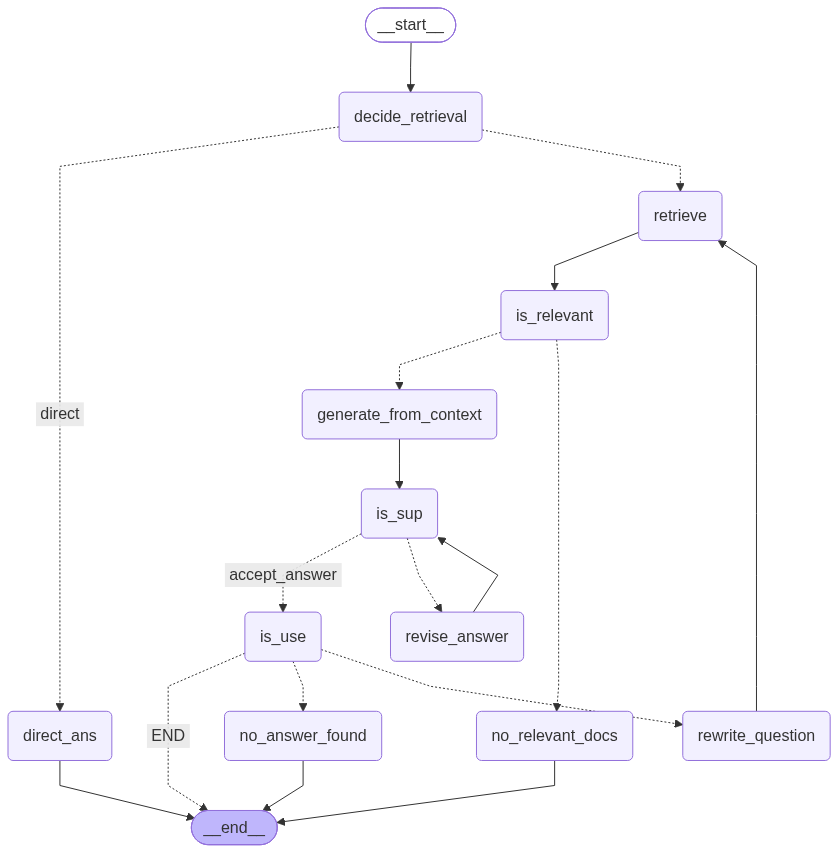

In [26]:
g = StateGraph(State)
# Nodes
g.add_node('decide_retrieval', decide_retrieval)
g.add_node('direct_ans', direct_ans)
g.add_node('retrieve', retrieve)
g.add_node('is_relevant', is_relevant)
g.add_node('generate_from_context',generate_from_context)
g.add_node('no_relevant_docs',no_relevant_docs)
g.add_node("is_sup",is_sup)

g.add_node('revise_answer',revise_answer)
g.add_node("is_use", is_use)
g.add_node('no_answer_found',no_answer_found)

g.add_node("rewrite_question", rewrite_question)
# Edges
g.add_edge(START, 'decide_retrieval')
g.add_conditional_edges(
    'decide_retrieval',
    route_after_decide,
    {
        'retrieve': 'retrieve',
        'direct': 'direct_ans'
    }
)
g.add_edge('direct_ans', END)

g.add_edge('retrieve', 'is_relevant')
g.add_conditional_edges('is_relevant',
                        route_after_relevance,
                        {
                            'generate_from_context':'generate_from_context',
                            'no_relevant_docs':'no_relevant_docs'
                        })
g.add_edge('generate_from_context','is_sup')
g.add_edge('no_relevant_docs',END)
g.add_conditional_edges('is_sup',
                        route_after_sup,
                        {
                            'accept_answer':"is_use",
                            'revise_answer':'revise_answer'
                        })

g.add_edge('revise_answer','is_sup')
g.add_conditional_edges('is_use',
                        route_after_isuse,
                        {
                            'END':END,
                            'rewrite_question':'rewrite_question',
                            'no_answer_found':'no_answer_found'
                        })
# rewrite -> retrieve -> relevance -> ...
g.add_edge("rewrite_question", "retrieve")
app = g.compile()
app


### Testing the graph

In [ ]:
result = app.invoke(
    {
        "question": "Who is the CEO of NexaAI",
         
         
    }
)

print(result)

In [ ]:
ansr = retriever.invoke('Who is the CEO')
for d in ansr:
    print(d.page_content)
    print('-'*40)

Testing the Relevance Node

In [ ]:
relevance_node = is_relevant({
    'docs':ansr,
    'question':"Who is the CEO of NexaAI"
})
relevance_node

In [ ]:
for reld in relevance_node.get('docs'):
    print(reld.page_content)

Testing the Answer generation from Context Node

In [ ]:
resp = generate_from_context({
    "relevant_docs":ansr,
    'question':"Who is the CEO of NexaAI"
})
resp

In [ ]:

result = app.invoke(
    {
        "question": "What is the refund policy of NexaAI",
        "docs": [],
        "relevant_docs": [],
        "context": "",
        "answer": "",
    }
)

print(result["answer"])

In [ ]:
# -----------------------------
# Run the graph
# -----------------------------
initial_state = {
    "question": "Describe NexaAI's company culture.",
    "retrieval_query": "What is the refund policy of NexaAI",  # ✅ important
    "rewrite_tries": 0,                                        # ✅ important
    "docs": [],
    "relevant_docs": [],
    "context": "",
    "answer": "",
    "issup": "",
    "evidence": [],
    "retries": 0,
    "isuse": "not_useful",
    "use_reason": "",
}


result = app.invoke(
    initial_state
)

# -----------------------------
# Debug / inspection output (clean + complete)
# -----------------------------
print("\n===== RAG EXECUTION RESULT =====\n")

print("Question:", initial_state.get("question"))
print("Need Retrieval:", result.get("need_retrieval"))

# If you added these counters/fields in your State:
print("Rewrite tries (retrieval):", result.get("rewrite_tries", 0))
print("Support revise tries:", result.get("retries", 0))

print("\nRetrieval:")
print("  Total retrieved docs:", len(result.get("docs", []) or []))
print("  Relevant docs:", len(result.get("relevant_docs", []) or []))

# Optional: show sources/pages for relevant docs
relevant_docs = result.get("relevant_docs", []) or []
if relevant_docs:
    print("\nRelevant docs (source/page):")
    for i, d in enumerate(relevant_docs, 1):
        src = (d.metadata or {}).get("source", "unknown")
        page = (d.metadata or {}).get("page", None)
        title = (d.metadata or {}).get("title", "")
        extra = f", title={title}" if title else ""
        if page is not None:
            print(f"  {i}. source={src}, page={page}{extra}")
        else:
            print(f"  {i}. source={src}{extra}")

print("\nVerification (IsSUP):")
print("  issup:", result.get("issup"))
evidence = result.get("evidence", []) or []
if evidence:
    print("  evidence:")
    for e in evidence:
        print("   -", e)
else:
    print("  evidence: (none)")

print("\nUsefulness (IsUSE):")
print("  isuse:", result.get("isuse"))
print("  reason:", result.get("use_reason", ""))

print("\nFinal Answer:")
print(result.get("answer"))

print("\n===============================\n")


In [ ]:
print([doc for i, doc in enumerate(docs) if i in relevant_indices])

### Final Testing

In [28]:
# -----------------------------
# Run the graph
# -----------------------------
initial_state = {
    "question": "Describe NexaAI's company culture.",
    # "retrieval_query": "What is the refund policy of NexaAI",  # ✅ important
    "rewrite_tries": 0,                                        # ✅ important
    "docs": [],
    "relevant_docs": [],
    "context": "",
    "answer": "",
    "issup": "",
    "evidence": [],
    "retries": 0,
    "isuse": "not_useful",
    "use_reason": "",
}


result = app.invoke(
    initial_state
)

# -----------------------------
# Debug / inspection output (clean + complete)
# -----------------------------
print("\n===== RAG EXECUTION RESULT =====\n")

print("Question:", initial_state.get("question"))
print("Need Retrieval:", result.get("need_retrieval"))

# If you added these counters/fields in your State:
print("Rewrite tries (retrieval):", result.get("rewrite_tries", 0))
print("Support revise tries:", result.get("retries", 0))

print("\nRetrieval:")
print("  Total retrieved docs:", len(result.get("docs", []) or []))
print("  Relevant docs:", len(result.get("relevant_docs", []) or []))

# Optional: show sources/pages for relevant docs
relevant_docs = result.get("relevant_docs", []) or []
if relevant_docs:
    print("\nRelevant docs (source/page):")
    for i, d in enumerate(relevant_docs, 1):
        src = (d.metadata or {}).get("source", "unknown")
        page = (d.metadata or {}).get("page", None)
        title = (d.metadata or {}).get("title", "")
        extra = f", title={title}" if title else ""
        if page is not None:
            print(f"  {i}. source={src}, page={page}{extra}")
        else:
            print(f"  {i}. source={src}{extra}")

print("\nVerification (IsSUP):")
print("  issup:", result.get("issup"))
evidence = result.get("evidence", []) or []
if evidence:
    print("  evidence:")
    for e in evidence:
        print("   -", e)
else:
    print("  evidence: (none)")

print("\nUsefulness (IsUSE):")
print("  isuse:", result.get("isuse"))
print("  reason:", result.get("use_reason", ""))

print("\nFinal Answer:")
print(result.get("answer"))

print("\n===============================\n")



===== RAG EXECUTION RESULT =====

Question: Describe NexaAI's company culture.
Need Retrieval: True
Rewrite tries (retrieval): 0
Support revise tries: 0

Retrieval:
  Total retrieved docs: 2
  Relevant docs: 2

Relevant docs (source/page):
  1. source=./documents/Company_Profile.pdf, page=0, title=(anonymous)
  2. source=./documents/Company_Policies.pdf, page=0, title=(anonymous)

Verification (IsSUP):
  issup: fully_supported
  evidence:
   - NexaAI is committed to maintaining a fair, inclusive, and performance-driven workplace.
   - Our values guide how we build products, treat customers, and work as a team.
   - Employees are encouraged to maintain a healthy work-life balance.

Usefulness (IsUSE):
  isuse: useful
  reason: 

Final Answer:
NexaAI's company culture is described as a fair, inclusive, and performance-driven workplace. It is built upon the following core values and principles:

*   **Core Values:** These guide how they build products, treat customers, and work as a team

### Test 2

In [32]:
initial_st = {
    'question':'What is the refund policy of NexaAI'
}
result = app.invoke(
    initial_st
)

# -----------------------------
# Debug / inspection output (clean + complete)
# -----------------------------
print("\n===== RAG EXECUTION RESULT =====\n")

print("Question:", initial_st.get("question"))
print("Need Retrieval:", result.get("need_retrieval"))

# If you added these counters/fields in your State:
print("Rewrite tries (retrieval):", result.get("rewrite_tries", 0))
print("Support revise tries:", result.get("retries", 0))

print("\nRetrieval:")
print("  Total retrieved docs:", len(result.get("docs", []) or []))
print("  Relevant docs:", len(result.get("relevant_docs", []) or []))

# Optional: show sources/pages for relevant docs
relevant_docs = result.get("relevant_docs", []) or []
if relevant_docs:
    print("\nRelevant docs (source/page):")
    for i, d in enumerate(relevant_docs, 1):
        src = (d.metadata or {}).get("source", "unknown")
        page = (d.metadata or {}).get("page", None)
        title = (d.metadata or {}).get("title", "")
        extra = f", title={title}" if title else ""
        if page is not None:
            print(f"  {i}. source={src}, page={page}{extra}")
        else:
            print(f"  {i}. source={src}{extra}")

print("\nVerification (IsSUP):")
print("  issup:", result.get("issup"))
evidence = result.get("evidence", []) or []
if evidence:
    print("  evidence:")
    for e in evidence:
        print("   -", e)
else:
    print("  evidence: (none)")

print("\nUsefulness (IsUSE):")
print("  isuse:", result.get("isuse"))
print("  reason:", result.get("use_reason", ""))

print("\nFinal Answer:")
print(result.get("answer"))

print("\n===============================\n")



===== RAG EXECUTION RESULT =====

Question: What is the refund policy of NexaAI
Need Retrieval: True
Rewrite tries (retrieval): 0
Support revise tries: 0

Retrieval:
  Total retrieved docs: 4
  Relevant docs: 0

Verification (IsSUP):
  issup: None
  evidence: (none)

Usefulness (IsUSE):
  isuse: None
  reason: 

Final Answer:
No relevant document found.




In [35]:
print(result.get('docs')[1])

page_content='Pricing & Plans
NexaAI pricing is based on the number of active users and selected product modules. All plans
include standard security updates and product enhancements.
Starter Plan
Designed for small teams and early-stage adoption.

Price: ■2,499 per user per month

Access to NexaChat core features

Up to 5,000 queries per month

Email-based customer support

Shared cloud infrastructure
Growth Plan
Best suited for growing teams requiring deeper insights and integrations.

Price: ■5,999 per user per month

Access to NexaChat, NexaInsight, and NexaSupport

Advanced analytics and reporting

Third-party integrations (Slack, CRM, BI tools)

Priority email and chat support
Enterprise Plan
Tailored for large organizations with strict security, compliance, and scalability requirements.

Custom pricing based on usage and deployment model

All NexaAI products included

On-premise or private cloud deployment

Dedicated customer success manager

24x7 support with SLA

In [65]:
initial_st = {
    'question':'What are the different products NexaAI ofers'
}
result = app.invoke(
    initial_st
)

# -----------------------------
# Debug / inspection output (clean + complete)
# -----------------------------
print("\n===== RAG EXECUTION RESULT =====\n")

print("Question:", initial_st.get("question"))
print("Need Retrieval:", result.get("need_retrieval"))

# If you added these counters/fields in your State:
print("Rewrite tries (retrieval):", result.get("rewrite_tries", 0))
print("Support revise tries:", result.get("retries", 0))

print("\nRetrieval:")
print("  Total retrieved docs:", len(result.get("docs", []) or []))
print("  Relevant docs:", len(result.get("relevant_docs", []) or []))

# Optional: show sources/pages for relevant docs
relevant_docs = result.get("relevant_docs", []) or []
if relevant_docs:
    print("\nRelevant docs (source/page):")
    for i, d in enumerate(relevant_docs, 1):
        src = (d.metadata or {}).get("source", "unknown")
        page = (d.metadata or {}).get("page", None)
        title = (d.metadata or {}).get("title", "")
        extra = f", title={title}" if title else ""
        if page is not None:
            print(f"  {i}. source={src}, page={page}{extra}")
        else:
            print(f"  {i}. source={src}{extra}")

print("\nVerification (IsSUP):")
print("  issup:", result.get("issup"))
evidence = result.get("evidence", []) or []
if evidence:
    print("  evidence:")
    for e in evidence:
        print("   -", e)
else:
    print("  evidence: (none)")

print("\nUsefulness (IsUSE):")
print("  isuse:", result.get("isuse"))
print("  reason:", result.get("use_reason", ""))

print("\nFinal Answer:")
print(result.get("answer"))

print("\n===============================\n")



===== RAG EXECUTION RESULT =====

Question: What are the different products NexaAI ofers
Need Retrieval: True
Rewrite tries (retrieval): 0
Support revise tries: 0

Retrieval:
  Total retrieved docs: 4
  Relevant docs: 2

Relevant docs (source/page):
  1. source=./documents/Product_and_Pricing.pdf, page=0, title=(anonymous)
  2. source=./documents/Product_and_Pricing.pdf, page=2, title=(anonymous)

Verification (IsSUP):
  issup: fully_supported
  evidence:
   - NexaChat is an AI-powered internal assistant that allows employees to query company documents, policies, reports, and knowledge bases using natural language.
   - NexaInsight helps leadership and business teams analyze structured business data using natural language queries instead of traditional dashboards.
   - NexaSupport is an AI-driven customer support solution that automates responses to common customer queries while escalating complex issues to human agents.

Usefulness (IsUSE):
  isuse: useful
  reason: 

Final Answer:
N